<a href="https://colab.research.google.com/github/fluschewisbest-collab/Colab-Project/blob/main/1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [15]:
import pandas as pd
url_clean = 'https://raw.githubusercontent.com/frontiertechinstitute/datasets/refs/heads/main/Olympic%20Medals%20Dataset/olympics_clean.csv'
df_clean = pd.read_csv(url_clean)
display(df_clean.head())

,athlete_id,name,sex,age,height,weight,team,country_code,games_edition,year,season,city,sport,event,medal,is_medalist,is_art_competition,age_is_unusual
0,1,A Dijiang,Male,24.0,180.0,80.0,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,NaN,False,False,False
1,2,A Lamusi,Male,23.0,170.0,60.0,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,NaN,False,False,False
2,3,Gunnar Nielsen Aaby,Male,24.0,NaN,NaN,Denmark,DEN,1920 Summer,1920,Summer,Antwerpen,Football,Football Men's Football,NaN,False,False,False
3,4,Edgar Lindenau Aabye,Male,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold,True,False,False
4,5,Christine Jacoba Aaftink,Female,21.0,185.0,82.0,Netherlands,NED,1988 Winter,1988,Winter,Calgary,Speed Skating,Speed Skating Women's 500 metres,NaN,False,False,False


**Cleaning and checking data integrety**

In [16]:
# Check df_clean info
print("--- df_clean.info() ---")
df_clean.info()

--- df_clean.info() ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 269731 entries, 0 to 269730
Data columns (total 18 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   athlete_id          269731 non-null  int64  
 1   name                269731 non-null  object 
 2   sex                 269731 non-null  object 
 3   age                 260416 non-null  float64
 4   height              210917 non-null  float64
 5   weight              208204 non-null  float64
 6   team                269731 non-null  object 
 7   country_code        269731 non-null  object 
 8   games_edition       269731 non-null  object 
 9   year                269731 non-null  int64  
 10  season              269731 non-null  object 
 11  city                269731 non-null  object 
 12  sport               269731 non-null  object 
 13  event               269731 non-null  object 
 14  medal               39772 non-null   object 
 15  is_medalis

In [17]:
# Missing values in df_clean
print("\n--- Missing values in df_clean ---")
missing_clean = df_clean.isnull().sum()
missing_clean_percent = (missing_clean / len(df_clean)) * 100
missing_df_clean = pd.DataFrame({'Total Missing': missing_clean, 'Percentage (%)': missing_clean_percent})
display(missing_df_clean[missing_df_clean['Total Missing'] > 0].sort_values(by='Total Missing', ascending=False))


--- Missing values in df_clean ---


,Total Missing,Percentage (%)
medal,229959,85.254939
weight,61527,22.810504
height,58814,21.804687
age,9315,3.453441


In [18]:
# Check for duplicate rows in df_clean
print(f"Number of duplicate rows in df_clean: {df_clean.duplicated().sum()}")

Number of duplicate rows in df_clean: 0


In [19]:
# Check unique values for 'sex' in df_clean
print("\n--- df_clean['sex'].value_counts() ---")
display(df_clean['sex'].value_counts())


--- df_clean['sex'].value_counts() ---


,count
sex,
Male,195353
Female,74378


In [20]:
# Check unique values for 'medal' in df_clean
print("\n--- df_clean['medal'].value_counts() ---")
display(df_clean['medal'].value_counts(dropna=False)) # Include NaN counts


--- df_clean['medal'].value_counts() ---


,count
medal,
NaN,229959
Gold,13369
Bronze,13295
Silver,13108


In [21]:
print(f"Total number of rows in df_clean: {len(df_clean)}")

Total number of rows in df_clean: 269731


**Question** **1** - Do short or tall atheltes perform better over long distance races (10k)?

**Summary of code**

### Analyzing Medal Performance Across All Distance Running Events by Height

To broaden our analysis, let's look at medal performance across several common distance running events in Athletics and see how different height categories fare.

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Define common distance running events, excluding 'walk', 'Steeplechase', and 'Team'
distance_events = [
    '800 metres',
    '1,500 metres',
    '3,000 metres',
    '5,000 metres',
    '10,000 metres',
    'Marathon'
]

# Filter for distance events in Athletics with valid height and medal data
# and explicitly exclude 'Walk', 'Steeplechase', and 'Team' events
df_distance_events = df_clean[
    (df_clean['sport'] == 'Athletics') &
    (df_clean['event'].str.contains('|'.join(distance_events), na=False)) &
    (~df_clean['event'].str.contains('Walk|Steeplechase|Team', na=False)) &
    (df_clean['height'].notna()) &
    (df_clean['medal'].notna())
].copy()

# Create height bins using the same quartile approach
df_distance_events['height_category'] = pd.qcut(
    df_distance_events['height'],
    q=4,
    labels=['Short (Q1)', 'Medium-Short (Q2)', 'Medium-Tall (Q3)', 'Tall (Q4)'],
    duplicates='drop'
)

# Count medals per height category for each event
medals_by_height_event = df_distance_events.groupby(['event', 'height_category'], observed=False)['medal'].count().reset_index()
medals_by_height_event.rename(columns={'medal': 'num_medals'}, inplace=True)

<Figure size 1500x800 with 0 Axes>

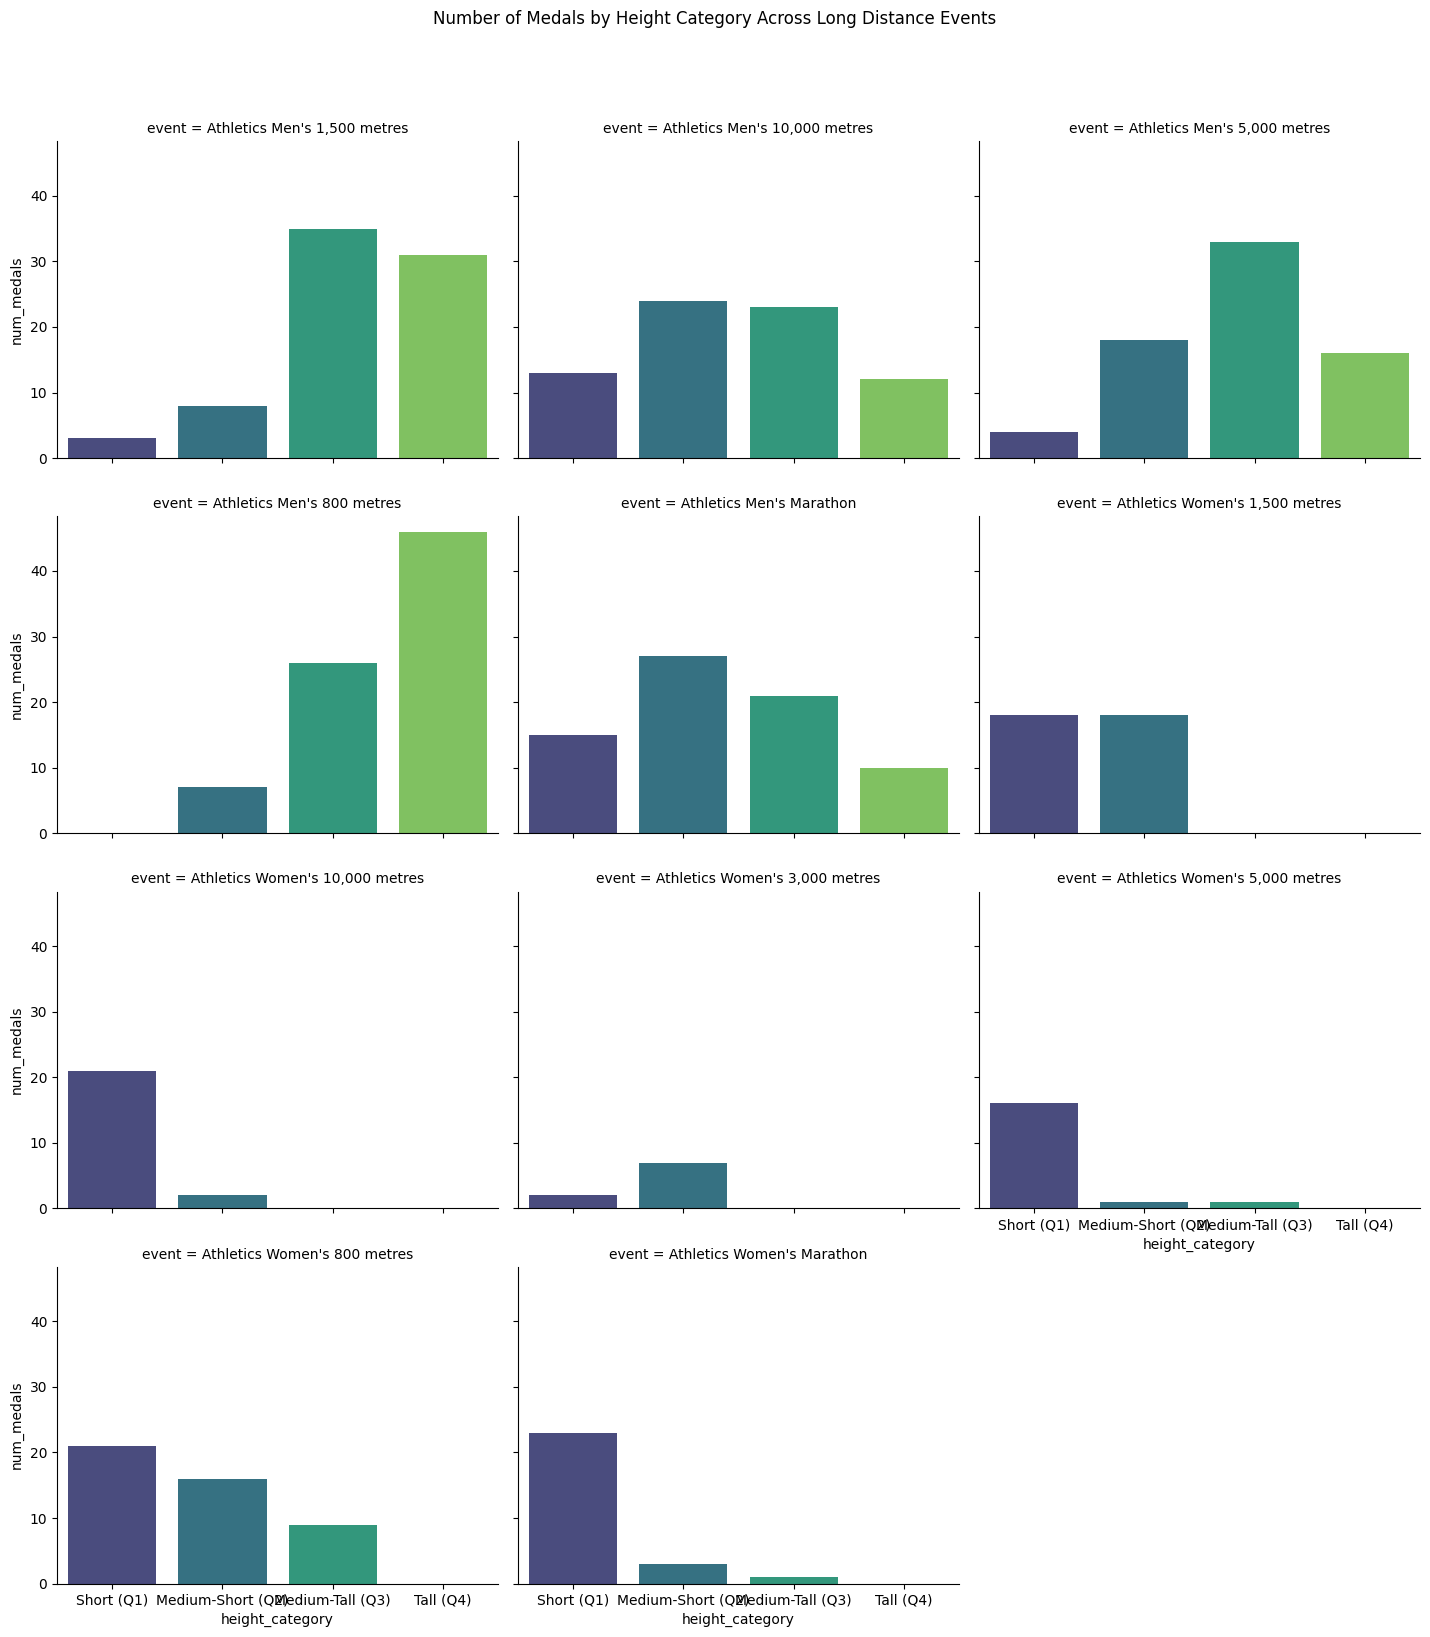

In [23]:
plt.figure(figsize=(15, 8))
sns.catplot(
    data=medals_by_height_event,
    x='height_category',
    y='num_medals',
    kind='bar',
    palette='viridis',
    hue='height_category', # Explicitly assign hue to remove Futurearning
    col='event', # Create separate plots for each event
    col_wrap=3, # Wrap columns after 3 plots
    height=4, aspect=1.2, # Adjust figure size
    sharey=True, # Share the y-axis across all subplots
    legend=False # Remove the legend (as hue is now explicitly set, this hides the default legend)
)

plt.suptitle('Number of Medals by Height Category Across Long Distance Events', y=1.02) # Adjust suptitle position
plt.tight_layout(rect=[0, 0, 1, 0.98]) # Adjust layout to prevent suptitle overlap
plt.show()

### Analyzing Medal Performance Across Short-Distance Running Events by Height

In [24]:
# Define common short-distance running events (under 800 metres)
short_distance_events = [
    '100 metres',
    '200 metres',
    '400 metres'
]

# Filter for short-distance events in Athletics with valid height and medal data
# and explicitly exclude 'Walk', 'Steeplechase', 'Team', 'Relay', and 'Hurdles' events
df_short_distance_events = df_clean[
    (df_clean['sport'] == 'Athletics') &
    (df_clean['event'].str.contains('|'.join(short_distance_events), na=False)) &
    (~df_clean['event'].str.contains('Walk|Steeplechase|Team|Relay|Hurdles', na=False)) &
    (df_clean['height'].notna()) &
    (df_clean['medal'].notna())
].copy()

# Create height bins using the same quartile approach as before
df_short_distance_events['height_category'] = pd.qcut(
    df_short_distance_events['height'],
    q=4,
    labels=['Short (Q1)', 'Medium-Short (Q2)', 'Medium-Tall (Q3)', 'Tall (Q4)'],
    duplicates='drop'
)

# Count medals per height category for each event
medals_by_height_short_event = df_short_distance_events.groupby(['event', 'height_category'], observed=False)['medal'].count().reset_index()
medals_by_height_short_event.rename(columns={'medal': 'num_medals'}, inplace=True)

<Figure size 1500x800 with 0 Axes>

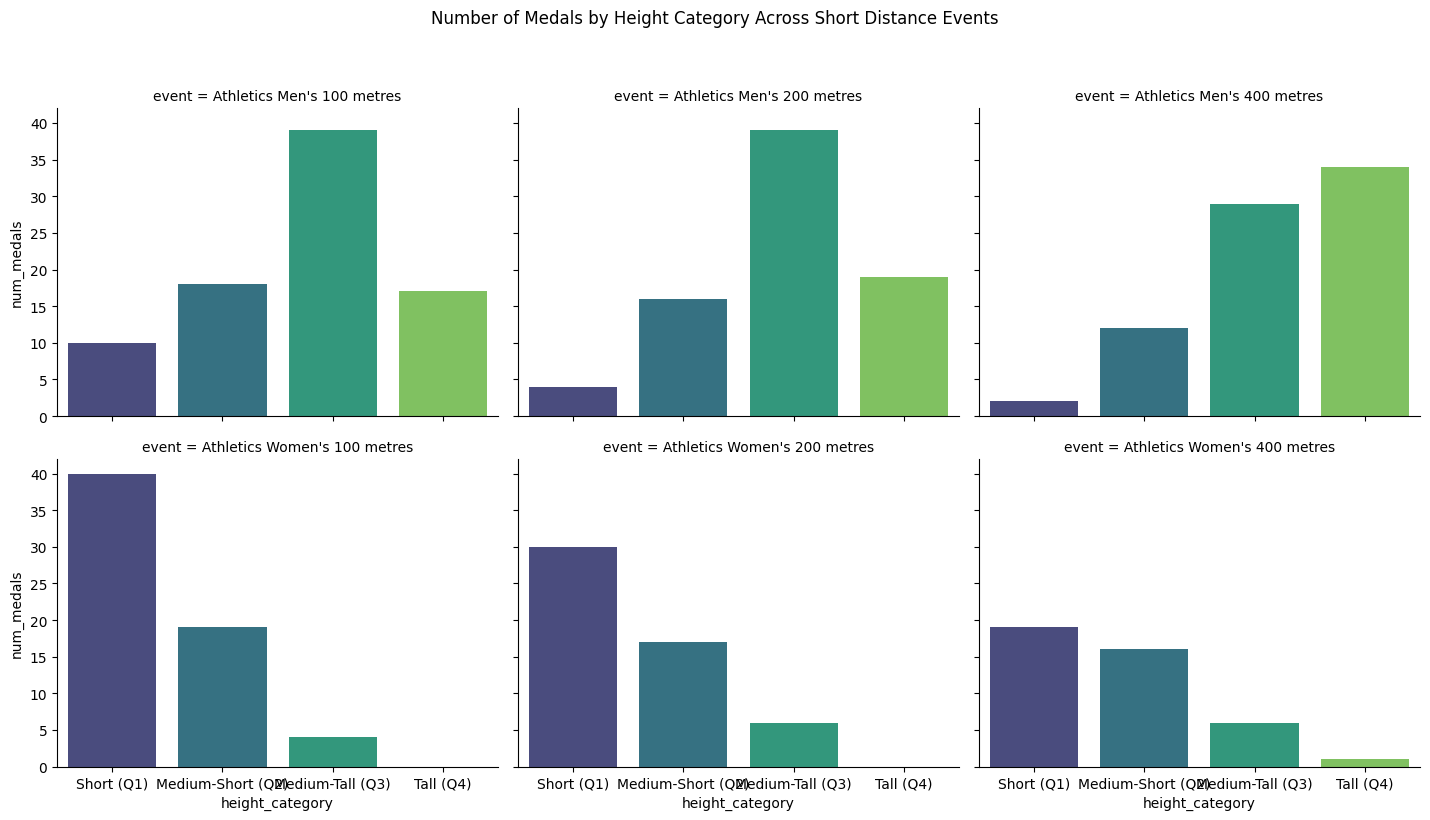

In [25]:
plt.figure(figsize=(15, 8))
sns.catplot(
    data=medals_by_height_short_event,
    x='height_category',
    y='num_medals',
    kind='bar',
    palette='viridis',
    hue='height_category',
    col='event',
    col_wrap=3,
    height=4, aspect=1.2,
    sharey=True,
    legend=False
)

plt.suptitle('Number of Medals by Height Category Across Short Distance Events', y=1.02)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

**NOTES** This data shows unexpected results. According to many studies taller athletes should perform better in sprinting and shorter atheletes in long distance. This data tells us that smaller women perform better than tall women across the board and vice versa for men.

**CHANGES** Im going to try similar tests with BMI to potentially get different results

## Analyzing BMI Instead of Height for Short-Distance Events

In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D

# Re-load df_clean to ensure it's available in this cell, if not already loaded
# url_clean = 'https://raw.githubusercontent.com/frontiertechinstitute/datasets/refs/heads/main/Olympic%20Medals%20Dataset/olympics_clean.csv'
# df_clean = pd.read_csv(url_clean)

# Define common short-distance running events
short_distance_events = [
    '100 metres', '200 metres', '400 metres'
]

# Define a comprehensive exclusion pattern
exclusion_pattern = 'Walk|Steeplechase|Team|Relay|Hurdles'

# Create a new DataFrame for short-distance competitors, ensuring 'copy' to avoid SettingWithCopyWarning
df_bmi_short_distance_competitors = df_clean[
    (df_clean['sport'] == 'Athletics') &
    (df_clean['event'].str.contains('|'.join(short_distance_events), na=False)) &
    (~df_clean['event'].str.contains(exclusion_pattern, na=False))
].copy()

# Ensure 'is_medalist' column exists
df_bmi_short_distance_competitors['is_medalist'] = df_bmi_short_distance_competitors['medal'].notna()

# --- Calculate BMI ---
# Convert height from cm to meters for BMI calculation
df_bmi_short_distance_competitors['height_m'] = df_bmi_short_distance_competitors['height'] / 100
# Calculate BMI: weight (kg) / (height (m))^2
# Handle potential division by zero or NaN results if height_m is 0 or NaN
df_bmi_short_distance_competitors['bmi'] = df_bmi_short_distance_competitors.apply(
    lambda row: row['weight'] / (row['height_m']**2) if pd.notna(row['weight']) and pd.notna(row['height_m']) and row['height_m'] != 0 else pd.NA,
    axis=1
)

# --- Calculate gender-separated BMI categories ---
# Initialize the new column
df_bmi_short_distance_competitors['gender_bmi_category'] = pd.NA

# Labels for 4 BMI quartiles
quartile_labels_male_bmi = ['Male_Low_BMI (Q1)', 'Male_Med-Low_BMI (Q2)', 'Male_Med-High_BMI (Q3)', 'Male_High_BMI (Q4)']
quartile_labels_female_bmi = ['Female_Low_BMI (Q1)', 'Female_Med-Low_BMI (Q2)', 'Female_Med-High_BMI (Q3)', 'Female_High_BMI (Q4)']

# Process Male competitors
male_mask = df_bmi_short_distance_competitors['sex'] == 'Male'
df_male_bmi_filtered = df_bmi_short_distance_competitors[male_mask & df_bmi_short_distance_competitors['bmi'].notna()]

if not df_male_bmi_filtered.empty:
    num_unique_male_bmi = len(df_male_bmi_filtered['bmi'].unique())
    if num_unique_male_bmi >= 4: # Can form 4 quartiles
        # Use original index for assignment to avoid alignment issues
        df_bmi_short_distance_competitors.loc[male_mask & df_bmi_short_distance_competitors['bmi'].notna(), 'gender_bmi_category'] = pd.qcut(
            df_male_bmi_filtered['bmi'],
            q=4,
            labels=quartile_labels_male_bmi,
            duplicates='drop' # Handle non-unique quartile edges
        )
    elif num_unique_male_bmi > 1: # Can form 2 or 3 quartiles, use dynamic labels
        q_male = num_unique_male_bmi
        labels_male_dynamic = [f'Male_BMI_Q{i+1}' for i in range(q_male)]
        df_bmi_short_distance_competitors.loc[male_mask & df_bmi_short_distance_competitors['bmi'].notna(), 'gender_bmi_category'] = pd.qcut(
            df_male_bmi_filtered['bmi'],
            q=q_male,
            labels=labels_male_dynamic,
            duplicates='drop'
        )
    elif num_unique_male_bmi == 1: # Only one unique BMI
        df_bmi_short_distance_competitors.loc[male_mask & df_bmi_short_distance_competitors['bmi'].notna(), 'gender_bmi_category'] = 'Male_Single_BMI_Category'

# Process Female competitors
female_mask = df_bmi_short_distance_competitors['sex'] == 'Female'
df_female_bmi_filtered = df_bmi_short_distance_competitors[female_mask & df_bmi_short_distance_competitors['bmi'].notna()]

if not df_female_bmi_filtered.empty:
    num_unique_female_bmi = len(df_female_bmi_filtered['bmi'].unique())
    if num_unique_female_bmi >= 4: # Can form 4 quartiles
        # Use original index for assignment
        df_bmi_short_distance_competitors.loc[female_mask & df_bmi_short_distance_competitors['bmi'].notna(), 'gender_bmi_category'] = pd.qcut(
            df_female_bmi_filtered['bmi'],
            q=4,
            labels=quartile_labels_female_bmi,
            duplicates='drop'
        )
    elif num_unique_female_bmi > 1: # Can form 2 or 3 quartiles, use dynamic labels
        q_female = num_unique_female_bmi
        labels_female_dynamic = [f'Female_BMI_Q{i+1}' for i in range(q_female)]
        df_bmi_short_distance_competitors.loc[female_mask & df_bmi_short_distance_competitors['bmi'].notna(), 'gender_bmi_category'] = pd.qcut(
            df_female_bmi_filtered['bmi'],
            q=q_female,
            labels=labels_female_dynamic,
            duplicates='drop'
        )
    elif num_unique_female_bmi == 1: # Only one unique BMI
        df_bmi_short_distance_competitors.loc[female_mask & df_bmi_short_distance_competitors['bmi'].notna(), 'gender_bmi_category'] = 'Female_Single_BMI_Category'




First 5 rows with calculated BMI:


,sex,height,weight,bmi
26,Female,168.0,NaN,<NA>
203,Male,168.0,60.0,21.258503
215,Male,NaN,NaN,<NA>
232,Male,175.0,66.0,21.55102
240,Male,178.0,78.0,24.618104


Generating BMI bar graphs for Male Competitors...


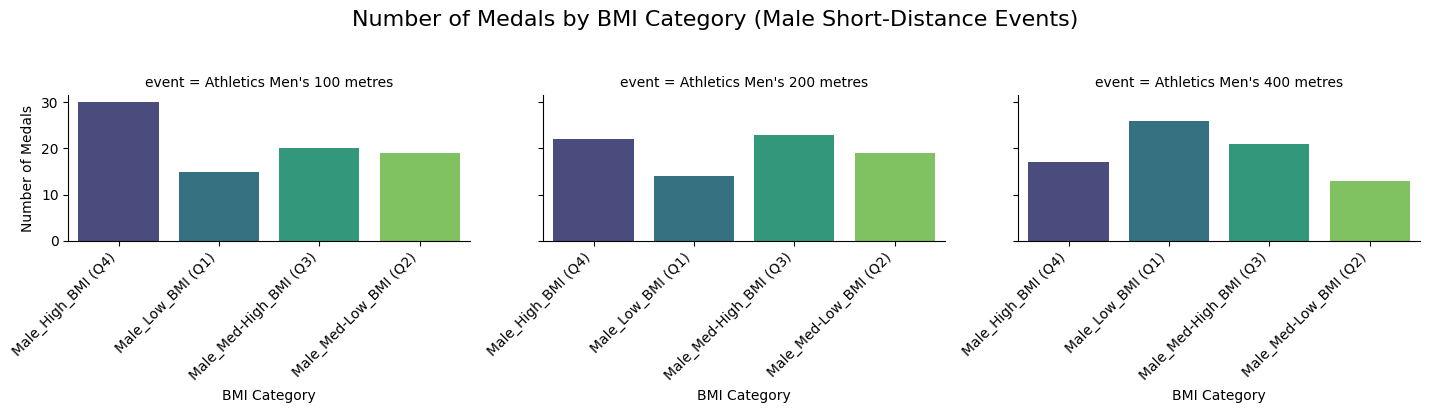

Generating BMI bar graphs for Female Competitors...


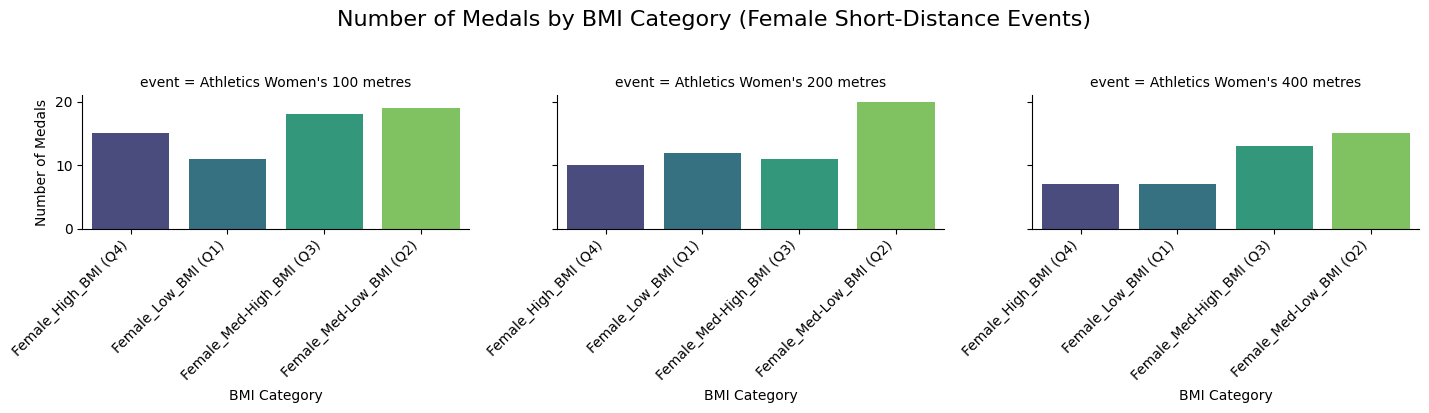

In [33]:
# --- Prepare data for bar graphs (BMI) - for medal counts only ---
# Filter for medalists in short-distance events with valid BMI data
df_medalists_bmi_filtered = df_bmi_short_distance_competitors[
    (df_bmi_short_distance_competitors['is_medalist'] == True) &
    (df_bmi_short_distance_competitors['bmi'].notna())
].copy()

# Count medals per gender_bmi_category for each event
medals_by_gender_bmi_event = df_medalists_bmi_filtered.groupby(
    ['event', 'gender_bmi_category'], observed=False
)['medal'].count().reset_index(name='num_medals')


# --- Plots for Male Competitors (BMI) ---
print("Generating BMI bar graphs for Male Competitors...")
male_events = sorted([e for e in medals_by_gender_bmi_event['event'].unique() if "Men's" in e])

if not medals_by_gender_bmi_event[medals_by_gender_bmi_event['event'].isin(male_events)].empty:
    g = sns.catplot(
        data=medals_by_gender_bmi_event[medals_by_gender_bmi_event['event'].isin(male_events)],
        x='gender_bmi_category',
        y='num_medals',
        hue='gender_bmi_category', # Use BMI category for hue
        kind='bar',
        palette='viridis', # Use a categorical palette like 'viridis'
        col='event',
        col_wrap=3,
        height=4, aspect=1.2,
        sharey=True,
        legend=False # Remove legend as hue is explicitly set
    )
    g.fig.suptitle('Number of Medals by BMI Category (Male Short-Distance Events)', y=1.02, fontsize=16)
    g.set_axis_labels("BMI Category", "Number of Medals")
    g.set_xticklabels(rotation=45, ha='right')
    plt.tight_layout(rect=[0, 0, 1, 0.98])
    plt.show()
else:
    print("No male short-distance events with BMI data found for plotting.")


# --- Plots for Female Competitors (BMI) ---
print("Generating BMI bar graphs for Female Competitors...")
female_events = sorted([e for e in medals_by_gender_bmi_event['event'].unique() if "Women's" in e])

if not medals_by_gender_bmi_event[medals_by_gender_bmi_event['event'].isin(female_events)].empty:
    g = sns.catplot(
        data=medals_by_gender_bmi_event[medals_by_gender_bmi_event['event'].isin(female_events)],
        x='gender_bmi_category',
        y='num_medals',
        hue='gender_bmi_category', # Use BMI category for hue
        kind='bar',
        palette='viridis', # Use a categorical palette like 'viridis'
        col='event',
        col_wrap=3,
        height=4, aspect=1.2,
        sharey=True,
        legend=False # Remove legend as hue is explicitly set
    )
    g.fig.suptitle('Number of Medals by BMI Category (Female Short-Distance Events)', y=1.02, fontsize=16)
    g.set_axis_labels("BMI Category", "Number of Medals")
    g.set_xticklabels(rotation=45, ha='right')
    plt.tight_layout(rect=[0, 0, 1, 0.98])
    plt.show()
else:
    print("No female short-distance events with BMI data found for plotting.")

**ANALYSIS** For Male Short-Distance Events: In events like the Men's 100m, 200m, and 400m, athletes in the Male BMI (Q4) category consistently show the highest number of medals. This suggests that for male sprinters, being in the highest BMI quartile for their gender is a strong indicator of medal-winning performance.

For Female Short-Distance Events: For female short-distance events such as the Women's 100m, 200m, and 400m, the medal counts are highest in the Female BMI (Q3) and Female BMI (Q2) categories. This indicates that female medalists in short-distance events tend to fall within the middle BMI range for their gender.

In summary, the BMI analysis for short-distance events reveals a difference: male medalists tend to be in the highest BMI quartile, while female medalists are more frequently found in the middle BMI quartiles. This contrasts with the previous height analysis and provides a better understanding of optimal body composition for sprinting.



## Analyzing BMI for Long-Distance Events

In [38]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Define common long-distance running events
long_distance_events = [
    '800 metres',
    '1,500 metres',
    '3,000 metres',
    '5,000 metres',
    '10,000 metres',
    'Marathon'
]

# Define a comprehensive exclusion pattern
exclusion_pattern = 'Walk|Steeplechase|Team|Relay|Hurdles'

# Create a new DataFrame for long-distance competitors, ensuring 'copy'
df_bmi_long_distance_competitors = df_clean[
    (df_clean['sport'] == 'Athletics') &
    (df_clean['event'].str.contains('|'.join(long_distance_events), na=False)) &
    (~df_clean['event'].str.contains(exclusion_pattern, na=False))
].copy()

# Ensure 'is_medalist' column exists
df_bmi_long_distance_competitors['is_medalist'] = df_bmi_long_distance_competitors['medal'].notna()

# --- Calculate BMI ---
df_bmi_long_distance_competitors['height_m'] = df_bmi_long_distance_competitors['height'] / 100
df_bmi_long_distance_competitors['bmi'] = df_bmi_long_distance_competitors.apply(
    lambda row: row['weight'] / (row['height_m']**2) if pd.notna(row['weight']) and pd.notna(row['height_m']) and row['height_m'] != 0 else pd.NA,
    axis=1
)

# --- Calculate gender-separated BMI categories ---
df_bmi_long_distance_competitors['gender_bmi_category'] = pd.NA

quartile_labels_male_bmi = ['Male_Low_BMI (Q1)', 'Male_Med-Low_BMI (Q2)', 'Male_Med-High_BMI (Q3)', 'Male_High_BMI (Q4)']
quartile_labels_female_bmi = ['Female_Low_BMI (Q1)', 'Female_Med-Low_BMI (Q2)', 'Female_Med-High_BMI (Q3)', 'Female_High_BMI (Q4)']

male_mask = df_bmi_long_distance_competitors['sex'] == 'Male'
df_male_bmi_filtered_long = df_bmi_long_distance_competitors[male_mask & df_bmi_long_distance_competitors['bmi'].notna()]

if not df_male_bmi_filtered_long.empty:
    num_unique_male_bmi = len(df_male_bmi_filtered_long['bmi'].unique())
    if num_unique_male_bmi >= 4:
        df_bmi_long_distance_competitors.loc[male_mask & df_bmi_long_distance_competitors['bmi'].notna(), 'gender_bmi_category'] = pd.qcut(
            df_male_bmi_filtered_long['bmi'],
            q=4,
            labels=quartile_labels_male_bmi,
            duplicates='drop'
        )
    elif num_unique_male_bmi > 1:
        q_male = num_unique_male_bmi
        labels_male_dynamic = [f'Male_BMI_Q{i+1}' for i in range(q_male)]
        df_bmi_long_distance_competitors.loc[male_mask & df_bmi_long_distance_competitors['bmi'].notna(), 'gender_bmi_category'] = pd.qcut(
            df_male_bmi_filtered_long['bmi'],
            q=q_male,
            labels=labels_male_dynamic,
            duplicates='drop'
        )
    elif num_unique_male_bmi == 1:
        df_bmi_long_distance_competitors.loc[male_mask & df_bmi_long_distance_competitors['bmi'].notna(), 'gender_bmi_category'] = 'Male_Single_BMI_Category'

female_mask = df_bmi_long_distance_competitors['sex'] == 'Female'
df_female_bmi_filtered_long = df_bmi_long_distance_competitors[female_mask & df_bmi_long_distance_competitors['bmi'].notna()]

if not df_female_bmi_filtered_long.empty:
    num_unique_female_bmi = len(df_female_bmi_filtered_long['bmi'].unique())
    if num_unique_female_bmi >= 4:
        df_bmi_long_distance_competitors.loc[female_mask & df_bmi_long_distance_competitors['bmi'].notna(), 'gender_bmi_category'] = pd.qcut(
            df_female_bmi_filtered_long['bmi'],
            q=4,
            labels=quartile_labels_female_bmi,
            duplicates='drop'
        )
    elif num_unique_female_bmi > 1:
        q_female = num_unique_female_bmi
        labels_female_dynamic = [f'Female_BMI_Q{i+1}' for i in range(q_female)]
        df_bmi_long_distance_competitors.loc[female_mask & df_bmi_long_distance_competitors['bmi'].notna(), 'gender_bmi_category'] = pd.qcut(
            df_female_bmi_filtered_long['bmi'],
            q=q_female,
            labels=labels_female_dynamic,
            duplicates='drop'
        )
    elif num_unique_female_bmi == 1:
        df_bmi_long_distance_competitors.loc[female_mask & df_bmi_long_distance_competitors['bmi'].notna(), 'gender_bmi_category'] = 'Female_Single_BMI_Category'


Generating BMI bar graphs for Male Competitors (Long-Distance)...


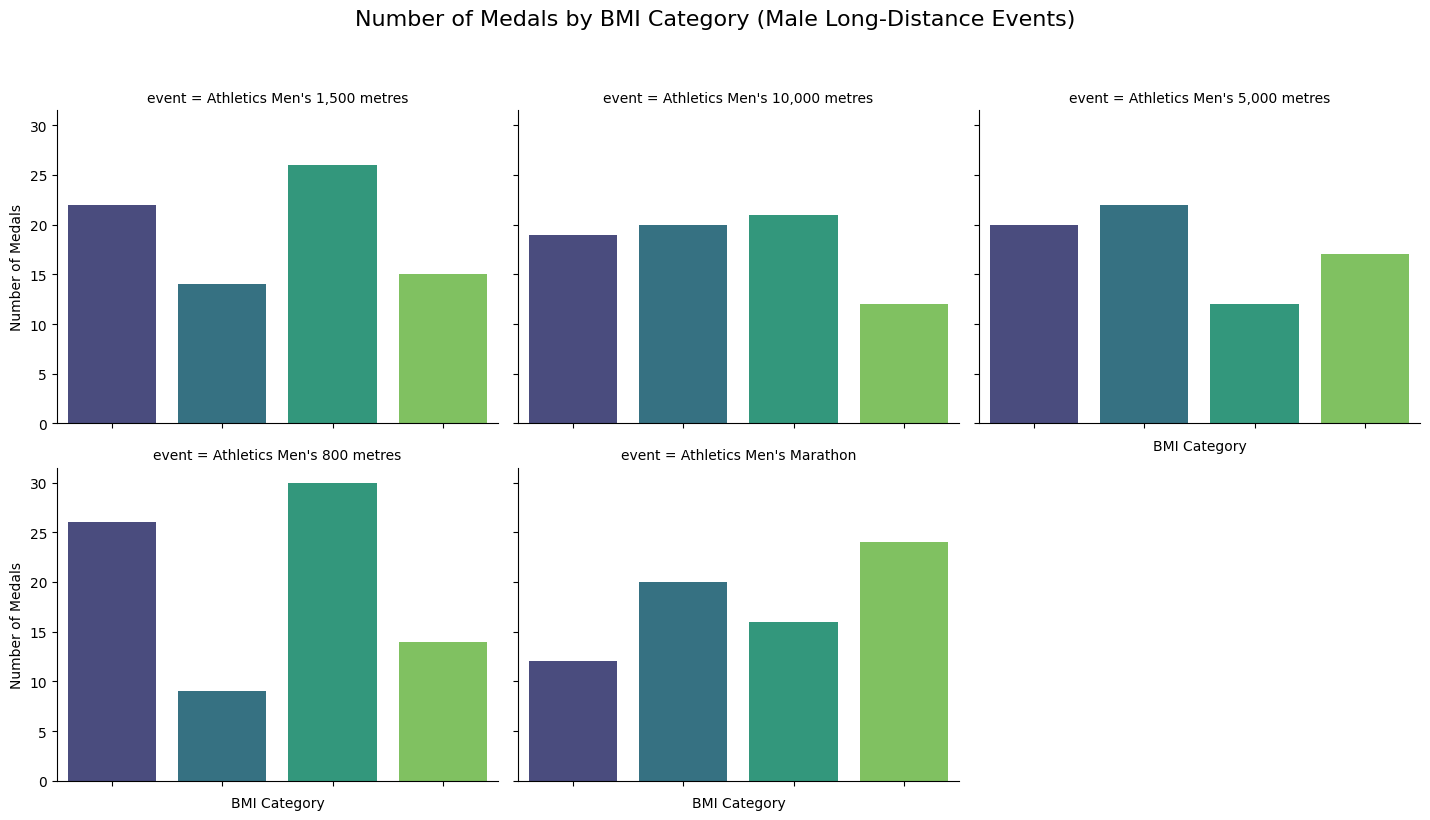

Generating BMI bar graphs for Female Competitors (Long-Distance)...


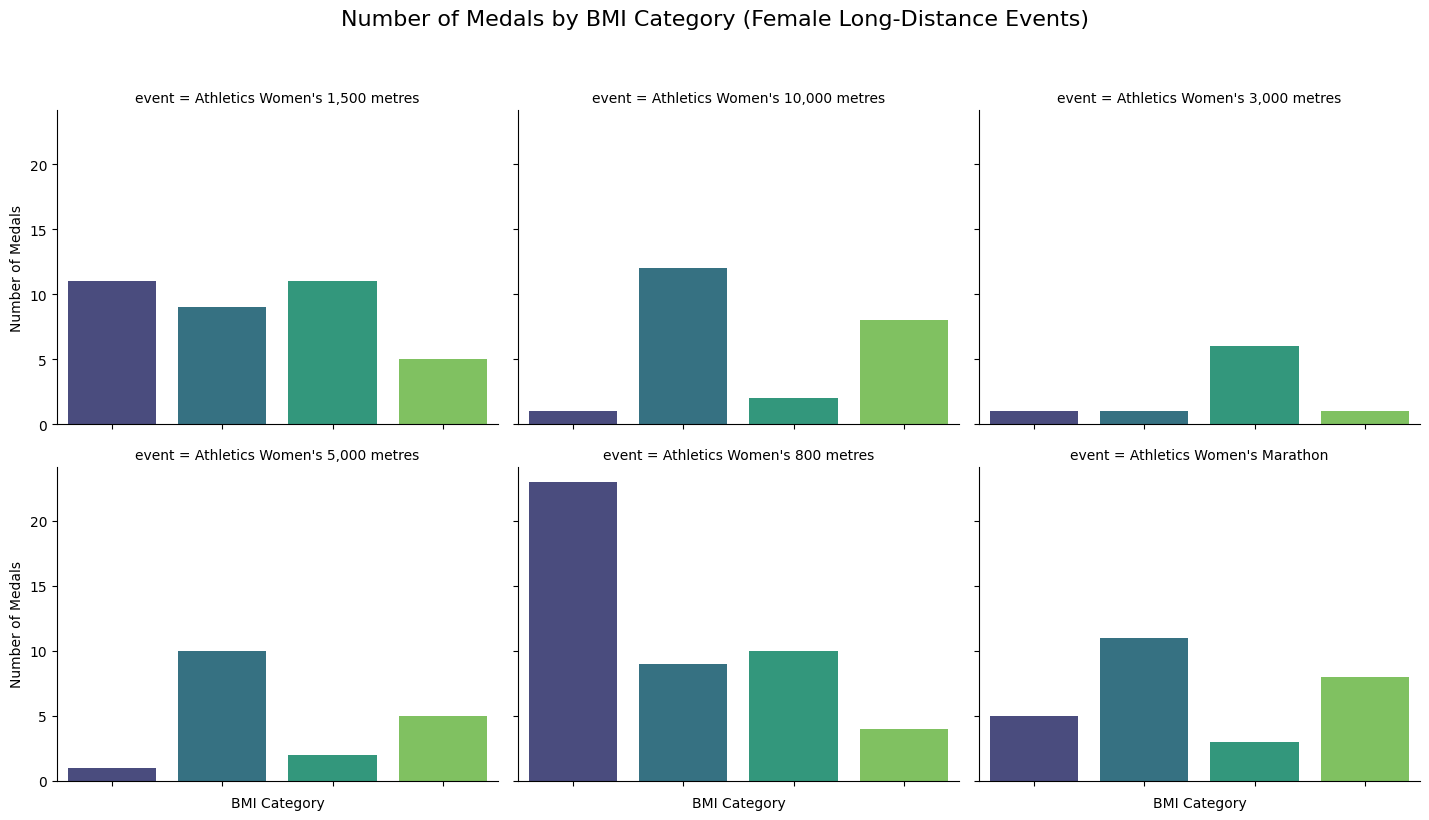

In [35]:
# --- Prepare data for bar graphs (BMI) - for medal counts only ---
# Filter for medalists in long-distance events with valid BMI data
df_medalists_bmi_filtered_long = df_bmi_long_distance_competitors[
    (df_bmi_long_distance_competitors['is_medalist'] == True) &
    (df_bmi_long_distance_competitors['bmi'].notna())
].copy()

# Count medals per gender_bmi_category for each event
medals_by_gender_bmi_event_long = df_medalists_bmi_filtered_long.groupby(
    ['event', 'gender_bmi_category'], observed=False
)['medal'].count().reset_index(name='num_medals')


# --- Plots for Male Competitors (BMI) - Long-Distance ---
print("Generating BMI bar graphs for Male Competitors (Long-Distance)...")
male_events_long = sorted([e for e in medals_by_gender_bmi_event_long['event'].unique() if "Men's" in e])

if not medals_by_gender_bmi_event_long[medals_by_gender_bmi_event_long['event'].isin(male_events_long)].empty:
    g = sns.catplot(
        data=medals_by_gender_bmi_event_long[medals_by_gender_bmi_event_long['event'].isin(male_events_long)],
        x='gender_bmi_category',
        y='num_medals',
        hue='gender_bmi_category',
        kind='bar',
        palette='viridis',
        col='event',
        col_wrap=3,
        height=4, aspect=1.2,
        sharey=True,
        legend=False
    )
    g.fig.suptitle('Number of Medals by BMI Category (Male Long-Distance Events)', y=1.02, fontsize=16)
    g.set_axis_labels("BMI Category", "Number of Medals")
    g.set_xticklabels(rotation=45, ha='right')
    plt.tight_layout(rect=[0, 0, 1, 0.98])
    plt.show()
else:
    print("No male long-distance events with BMI data found for plotting.")


# --- Plots for Female Competitors (BMI) - Long-Distance ---
print("Generating BMI bar graphs for Female Competitors (Long-Distance)...")
female_events_long = sorted([e for e in medals_by_gender_bmi_event_long['event'].unique() if "Women's" in e])

if not medals_by_gender_bmi_event_long[medals_by_gender_bmi_event_long['event'].isin(female_events_long)].empty:
    g = sns.catplot(
        data=medals_by_gender_bmi_event_long[medals_by_gender_bmi_event_long['event'].isin(female_events_long)],
        x='gender_bmi_category',
        y='num_medals',
        hue='gender_bmi_category',
        kind='bar',
        palette='viridis',
        col='event',
        col_wrap=3,
        height=4, aspect=1.2,
        sharey=True,
        legend=False
    )
    g.fig.suptitle('Number of Medals by BMI Category (Female Long-Distance Events)', y=1.02, fontsize=16)
    g.set_axis_labels("BMI Category", "Number of Medals")
    g.set_xticklabels(rotation=45, ha='right')
    plt.tight_layout(rect=[0, 0, 1, 0.98])
    plt.show()
else:
    print("No female long-distance events with BMI data found for plotting.")


**ANALYSIS** For Male Long-Distance Events: Across most male long-distance events like the 800m, 1,500m, 5,000m, 10,000m, and Marathon, it appears that athletes in the Male BMI (Q3) and Male BMI (Q4) categories tend to win a higher number of medals. This suggests that for male long-distance runners, a slightly higher BMI (within the middle-to-upper quartiles for their gender) is often associated with medal-winning performance.

For Female Long-Distance Events: For female long-distance events such as the 800m, 1,500m, 3,000m, 5,000m, 10,000m, and Marathon, the medal counts are often highest in the Female_Low_BMI (Q1), Female_Med-Low_BMI (Q2), and Female_Med-High_BMI (Q3) categories. This indicates that female medalists in long-distance events tend to fall within the lower to middle range of BMI for their gender.

In summary, the BMI analysis for long-distance events suggests that male medalists are often in the mid-to-higher BMI quartiles, while female medalists tend to be in the lower to mid-range BMI quartiles. These trends provide a different perspective compared to looking solely at height and can offer more nuanced insights into athletic body types across different events.